In [86]:
# Data manipulation
import pandas as pd
import numpy as np
from collections import Counter

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from category_encoders.binary import BinaryEncoder

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    classification_report, accuracy_score, precision_score, recall_score, f1_score
)

# Dimensionality reduction
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Visualization
import matplotlib.pyplot as plt

In [120]:
import warnings
warnings.filterwarnings('ignore')

In [121]:
df_appliction = pd.read_csv('./data/cleaned_data/applications.csv')

In [122]:
df_completions = pd.read_csv('./data/cleaned_data/completions.csv')

In [133]:
df_merged = df_appliction.merge(right = df_completions, how = 'inner', on='unique_id', suffixes=('_app' , '_comp'))

In [124]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7929 entries, 0 to 7928
Data columns (total 32 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   unique_id                                                                            7929 non-null   object 
 1   subscription_status                                                                  7929 non-null   object 
 2   voyage_role                                                                          7929 non-null   object 
 3   gender                                                                               7929 non-null   object 
 4   goal                                                                                 7929 non-null   object 
 5   source                                                                               7929 

In [125]:
# Drop rows with missing target
df_merged = df_merged.dropna(subset=['completed_voyage'])

# Drop high cardinality / mostly null columns
drop_cols = [
    'timestamp_app', 'timestamp_comp', 'certificate_issue_date',
    'source_other', 'what_is_the_name_of_the_project_if_there_isnt_a_name_you_can_just_write_no_name',
    'what_is_your_voyage', 'updated_voyage_start_date'
]
df_merged.drop(columns=drop_cols, inplace=True, errors='ignore')

# Fill NaNs
categorical_cols = df_merged.select_dtypes(include='object').columns
df_merged[categorical_cols] = df_merged[categorical_cols].fillna('missing')
numerical_cols = df_merged.select_dtypes(include='number').columns
df_merged[numerical_cols] = df_merged[numerical_cols].fillna(df_merged[numerical_cols].median())

# Encode target
df_merged['completed_voyage'] = df_merged['completed_voyage'].replace({'Yes': 'Yes', 'No': 'No', 'undefined': 'No'})

# Drop identifier
df_merged.drop(columns=['unique_id'], inplace=True)

# Report shape
print("Preprocessed shape:", df_merged.shape)
df_merged.head()


Preprocessed shape: (7929, 27)


,subscription_status,voyage_role,gender,goal,source,country_name_from_country,voyage_from_voyage_signups,application_age_in_days,application_day_of_week,no_voyages_started,...,subscription_status_week,has_voyage,timestamp,completed_voyage,completion_status,what_is_your_tier,on_a_scale_of_0_10_how_likely_are_you_to_recommend_chingu_to_a_friend_or_colleagues,status_from_voyage_signups_link,role_from_voyage_signups_link,product
0,Active,Scrum Master,FEMALE,GAIN EXPERIENCE,The Job Hackers,Canada,missing,13.0,3. Tuesday,0.0,...,8.0,0,2025-02-17 23:39:00,No,Incomplete Agile Leaders Course,Tier 2,10.0,not_defined,Scrum Master,SUBSCRIPTION - Junior Professional
1,Active,Developer,MALE,GAIN EXPERIENCE,PERSONAL NETWORK,India,missing,13.0,3. Tuesday,0.0,...,8.0,0,2022-09-11 09:46:00,No,No commits,Tier 2,10.0,not_defined,Developer,no_product
2,Active,Developer,MALE,GAIN EXPERIENCE,PERSONAL NETWORK,India,missing,13.0,3. Tuesday,0.0,...,8.0,0,2021-10-10 10:58:00,Yes,missing,Tier 1,10.0,not_defined,Developer,no_product
3,Active,Scrum Master,FEMALE,GAIN EXPERIENCE,PERSONAL NETWORK,United Kingdom,V53,59.0,6. Friday,2.0,...,1.0,1,2025-02-23 08:51:00,Yes,Cert issued,Tier 3,10.0,not_defined,Scrum Master,SUBSCRIPTION - Junior Professional
4,Active,Scrum Master,FEMALE,GAIN EXPERIENCE,PERSONAL NETWORK,United Kingdom,V54,59.0,6. Friday,2.0,...,1.0,1,2025-02-23 08:51:00,Yes,Cert issued,Tier 3,10.0,not_defined,Scrum Master,SUBSCRIPTION - Junior Professional


PCA reduced features from 86 to 59
PCA components contributing to 95% variance: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]


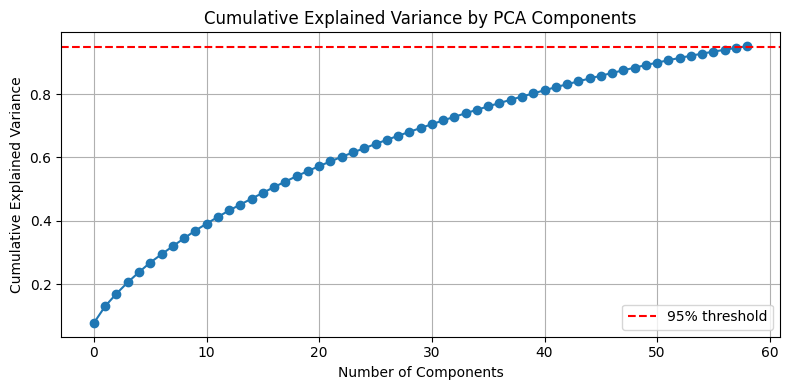

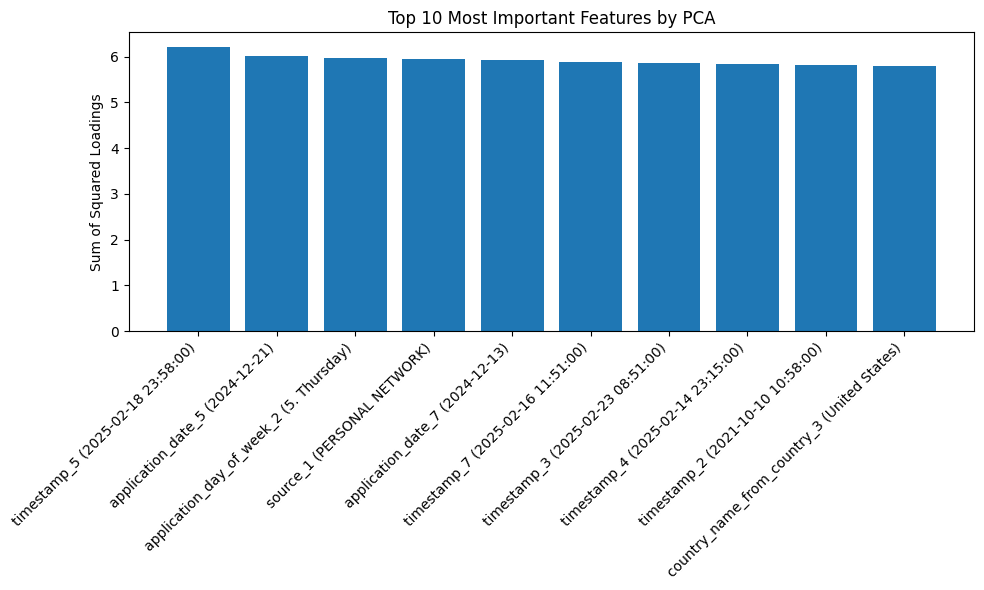

Selected features by SVM:
['subscription_status_0', 'voyage_role_0', 'gender_0', 'gender_1', 'goal_0', 'goal_1', 'goal_2', 'source_0', 'source_2', 'source_3', 'country_name_from_country_0', 'country_name_from_country_1', 'country_name_from_country_3', 'country_name_from_country_4', 'country_name_from_country_5', 'country_name_from_country_6', 'voyage_from_voyage_signups_1', 'voyage_from_voyage_signups_3', 'voyage_from_voyage_signups_4', 'application_day_of_week_0', 'no_voyages_started', 'application_date_0', 'application_date_2', 'application_date_3', 'application_date_4', 'application_date_5', 'application_date_7', 'application_date_8', 'updated_voyage_number_0', 'updated_voyage_number_4', 'has_voyage', 'timestamp_1', 'timestamp_2', 'timestamp_3', 'timestamp_4', 'timestamp_5', 'timestamp_6', 'timestamp_7', 'timestamp_8', 'timestamp_9', 'completion_status_0', 'completion_status_1', 'completion_status_2', 'completion_status_3', 'completion_status_4', 'completion_status_5', 'what_is_your

In [126]:

# Data preprocessing for modeling
df = df_merged.copy()

# Drop rows with missing target
df = df.dropna(subset=['completed_voyage'])

# Drop high cardinality / mostly null columns
drop_cols = [
    'timestamp_app', 'timestamp_comp', 'certificate_issue_date',
    'source_other', 'what_is_the_name_of_the_project_if_there_isnt_a_name_you_can_just_write_no_name',
    'what_is_your_voyage', 'updated_voyage_start_date' ,'unique_id'
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Fill NaNs
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna('missing')
numerical_cols = df.select_dtypes(include='number').columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Encode target
df['completed_voyage'] = df['completed_voyage'].replace({'Yes': 'Yes', 'No': 'No', 'undefined': 'No'})

# Encode target with LabelEncoder
y = LabelEncoder().fit_transform(df['completed_voyage'])
X = df.drop(columns=['completed_voyage', 'unique_id'], errors='ignore')
original_df = X.copy()

# Binary Encoding
encoder = BinaryEncoder()
X_encoded = encoder.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# PCA to inspect variance
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced features from", X_scaled.shape[1], "to", X_pca.shape[1])

# Identify which PCA components contribute to 95% variance
explained_ratios = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_ratios)
components_above_95 = np.where(cumulative_variance <= 0.95)[0].tolist()
print("PCA components contributing to 95% variance:", components_above_95)

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(explained_ratios), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Build mappings from encoded column to original label values
encoded_label_map = {}
for col in [col for col in categorical_cols if col in original_df.columns]:
    encoder_col = BinaryEncoder(cols=[col])
    encoder_col.fit(original_df[[col]])
    unique_values = original_df[col].dropna().unique().tolist()
    for i, encoded in enumerate(encoder_col.get_feature_names_out([col])):
        category_hint = unique_values[i] if i < len(unique_values) else ""
        encoded_label_map[encoded] = f"{encoded} ({category_hint})"

# Find top contributing features to those components
pca_components = pd.DataFrame(np.abs(pca.components_), columns=X_encoded.columns)
top_contributors = pca_components.iloc[:len(components_above_95)+1].sum().sort_values(ascending=False).head(10)

# Decode feature labels
decoded_labels = [encoded_label_map.get(col, col) for col in top_contributors.index]

# Plot
plt.figure(figsize=(10, 6))
plt.bar(decoded_labels, top_contributors.values)
plt.title("Top 10 Most Important Features by PCA")
plt.ylabel("Sum of Squared Loadings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature importance via Linear SVM
svm = LinearSVC(C=0.01, penalty='l1', dual=False, max_iter=2000)
svm.fit(X_scaled, y)

# Get important feature indices and names
feature_mask = svm.coef_[0] != 0
selected_features = X_encoded.columns[feature_mask]

print("Selected features by SVM:")
print(selected_features.tolist())

In [127]:
# Build mapping from binary-encoded column to base categorical column
encoded_label_map = {}
for col in categorical_cols:
    if col not in original_df.columns:
        continue  # skip if not present

    encoder = BinaryEncoder(cols=[col])
    encoder.fit(original_df[[col]])

    binary_cols = encoder.get_feature_names_out([col])
    for bcol in binary_cols:
        encoded_label_map[bcol] = col  # map encoded col back to original col name

# Now remap selected_features using this map
original_feature_names = []
seen = set()

for feat in selected_features:
    base = re.sub(r'_\d+$', '', feat)
    mapped = encoded_label_map.get(base, base)
    if mapped not in seen:
        original_feature_names.append(mapped)
        seen.add(mapped)

print("Mapped original feature names:")
print(original_feature_names)

Mapped original feature names:
['subscription_status', 'voyage_role', 'gender', 'goal', 'source', 'country_name_from_country', 'voyage_from_voyage_signups', 'application_day_of_week', 'no_voyages_started', 'application_date', 'updated_voyage_number', 'has_voyage', 'timestamp', 'completion_status', 'what_is_your_tier', 'on_a_scale_of_0_10_how_likely_are_you_to_recommend_chingu_to_a_friend_or_colleagues', 'role_from_voyage_signups_link', 'product']


In [116]:
def evaluate_model(name, model, X, y_true, label_encoder=None, multi_class_handling=True):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import (
        confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
        classification_report
    )
    from sklearn.preprocessing import label_binarize

    y_pred = model.predict(X)

    # Try to get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X)
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X)
    else:
        y_prob = None

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    fpr, tpr, auc = None, None, None

    # ROC & AUC logic
    if y_prob is not None and multi_class_handling:
        if isinstance(y_prob, np.ndarray) and y_prob.ndim == 1:
            # Binary case, single vector
            auc = roc_auc_score(y_true, y_prob)
            fpr, tpr, _ = roc_curve(y_true, y_prob)
        elif isinstance(y_prob, np.ndarray) and y_prob.shape[1] == 2:
            # Binary, 2-column proba
            auc = roc_auc_score(y_true, y_prob[:, 1])
            fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
        elif isinstance(y_prob, np.ndarray) and y_prob.shape[1] > 2:
            # Multiclass
            classes = np.unique(y_true)
            y_bin = label_binarize(y_true, classes=classes)

            if y_prob.shape[1] != y_bin.shape[1]:
                print(f"[Warning] Truncating y_prob from {y_prob.shape} to match y_bin shape {y_bin.shape}.")
                y_prob = y_prob[:, :y_bin.shape[1]]

            auc = roc_auc_score(y_bin, y_prob, multi_class='ovr')
            fpr, tpr = {}, {}
            for i, class_label in enumerate(classes):
                fpr[class_label], tpr[class_label], _ = roc_curve(y_bin[:, i], y_prob[:, i])
                auc_class = roc_auc_score(y_bin[:, i], y_prob[:, i])
                class_name = label_encoder.inverse_transform([class_label])[0] if label_encoder else class_label
                plt.plot(fpr[class_label], tpr[class_label], label=f"{name} - {class_name} AUC = {auc_class:.2f}")

    # Final AUC and plot
    if auc is not None:
        print(f"{name} AUC: {auc:.4f}")

    if isinstance(fpr, dict) and isinstance(tpr, dict):
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    elif isinstance(fpr, np.ndarray) and isinstance(tpr, np.ndarray):
        plt.plot(fpr, tpr, label=f"{name} AUC = {auc:.2f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

/home/razieh_ghahartars/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/razieh_ghahartars/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression Best Params: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
LogisticRegression Best F1 Score: 0.9063


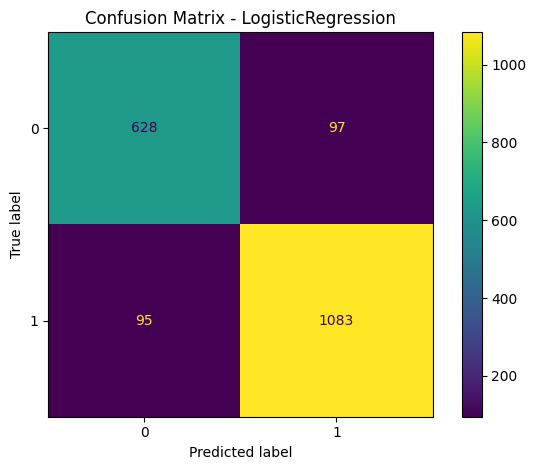

LogisticRegression AUC: 0.9571


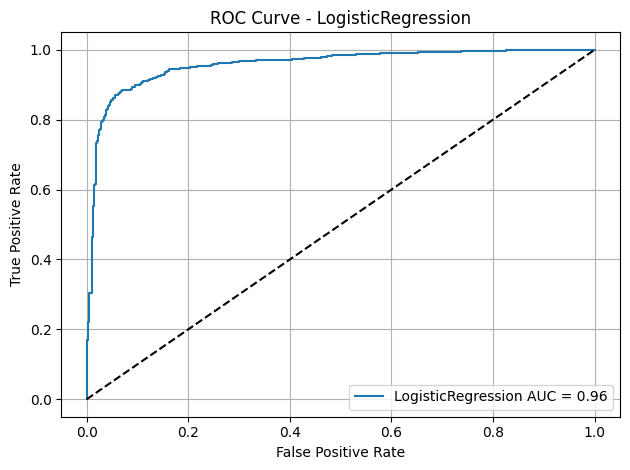

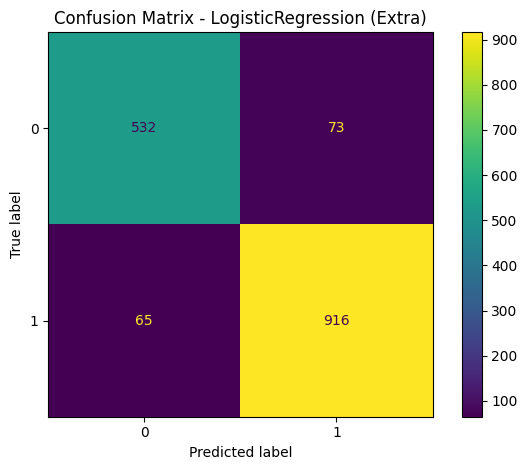

LogisticRegression (Extra) AUC: 0.9681


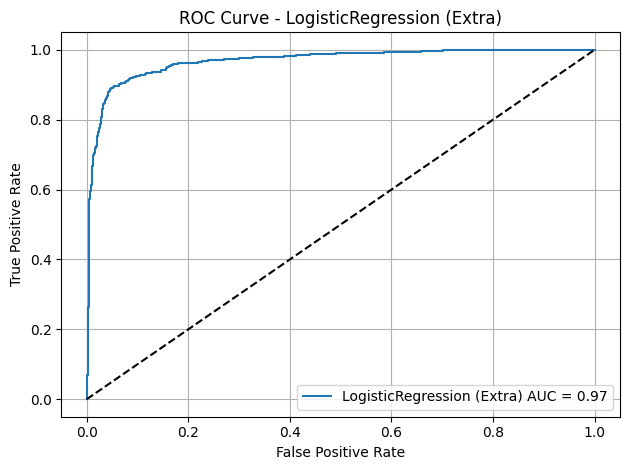

In [ ]:
# Target encoding
df = df_merged
X = df[original_feature_names]
y = df['completed_voyage'].replace({'Yes': 'Yes', 'No': 'NO', 'TBD': 'Yes', 'undefined': 'NO'})

# Fill missing values
categorical_cols = X.select_dtypes(include='object').columns
X[categorical_cols] = X[categorical_cols].fillna('missing')
numeric_cols = X.select_dtypes(include='number').columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Binary Encode full dataset
encoder = BinaryEncoder()
X_encoded = encoder.fit_transform(X)

# Train-test split
y_encoded = LabelEncoder().fit_transform(y)
X_intera, X_extra, y_intera, y_extra = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_intera, y_intera, test_size=0.3, random_state=42, stratify=y_intera)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
y_extra = label_encoder.transform(y_extra)
y_all = label_encoder.transform(y)

# Grid search training
grid_models = {
    'LogisticRegression': (LogisticRegression(), {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga', 'liblinear'],
        'max_iter': [1000, 3000, 5000]
    }),
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    })
}

for name, (model, param_grid) in grid_models.items():
    cv_folds = min(5, len(y_train)) if len(np.unique(y_train)) >= 2 else 2
    grid = GridSearchCV(model, param_grid, cv=cv_folds, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"{name} Best Params: {grid.best_params_}")
    print(f"{name} Best F1 Score: {grid.best_score_:.4f}")

    best_model = grid.best_estimator_
    pipeline = Pipeline([
        ('encoder', encoder),
        ('model', best_model)
    ])

    evaluate_model(name, best_model, X_test, y_test, label_encoder)
    evaluate_model(name + " (Extra)", best_model, X_extra, y_extra, label_encoder)



In [82]:
def evaluate_model(name, model, X, y_true, label_encoder=None, multi_class_handling=True):
    y_pred = model.predict(X)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X)
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X)
    else:
        y_prob = None

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    if y_prob is not None and multi_class_handling:
        if y_prob.ndim == 1 or y_prob.shape[1] == 1:
            y_prob = y_prob if y_prob.ndim == 1 else y_prob[:, 0]
            auc = roc_auc_score(y_true, y_prob)
            fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    else:
        classes = np.unique(y_true)
        y_bin = label_binarize(y_true, classes=classes)
        if y_prob.shape[1] != y_bin.shape[1]:
            print(f"[Warning] Truncating y_prob from {y_prob.shape} to match y_bin shape {y_bin.shape}.")
            y_prob = y_prob[:, :y_bin.shape[1]]
        auc = roc_auc_score(y_bin, y_prob, multi_class='ovr')
        fpr, tpr, _ = {}, {}, {}
        for i, class_label in enumerate(classes):
            fpr[class_label], tpr[class_label], _ = roc_curve(y_bin[:, i], y_prob[:, i])
            auc_class = roc_auc_score(y_bin[:, i], y_prob[:, i])
            plt.plot(fpr[class_label], tpr[class_label], label=f"{name} - Class {label_encoder.inverse_transform([class_label])[0]} AUC = {auc_class:.2f}")

    print(f"{name} AUC: {auc:.4f}")
    if fpr is not None and tpr is not None:
        for class_label in classes:
            plt.plot(fpr[class_label], tpr[class_label], label=f"{name} - Class {label_encoder.inverse_transform([class_label])[0]} AUC")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    y_true_labels = label_encoder.inverse_transform(y_true) if label_encoder else y_true
    y_pred_labels = label_encoder.inverse_transform(y_pred) if label_encoder else y_pred
    print("Classification Report:")
    print(classification_report(y_true_labels, y_pred_labels))

# Assuming df_merged is defined before this point
# For demonstration purposes, let's create a sample df_merged
data = {'completed_voyage': ['Yes', 'No', 'TBD', 'Yes', 'undefined', 'No'],
        'feature1': [1, 2, 3, 4, 5, 6],
        'feature2': ['A', 'B', 'A', 'C', 'B', 'C'],
        'unique_id': [101, 102, 103, 104, 105, 106]}
df_merged = pd.DataFrame(data)

# Data preprocessing
X = df_merged.drop(columns=['completed_voyage', 'unique_id'], errors='ignore').copy()
y = df_merged['completed_voyage'].replace({'Yes': 'Yes', 'No': 'No_TBD', 'TBD': 'No_TBD', 'undefined': 'No_TBD'})

# Fill missing values
categorical_cols = X.select_dtypes(include='object').columns
X[categorical_cols] = X[categorical_cols].fillna('missing')
numeric_cols = X.select_dtypes(include='number').columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Binary Encode full dataset
encoder = BinaryEncoder()
X_encoded = encoder.fit_transform(X)
X_intera, X_extra, y_intera, y_extra = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_intera, y_intera, test_size=0.3, random_state=42, stratify=y_intera)

# Label encode target
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
y_extra = label_encoder.transform(y_extra)
y_all = label_encoder.transform(y)

# Binary Encoding
encoder = BinaryEncoder()
X_encoded = encoder.fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_encoded)

# PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print("PCA reduced features from", X_scaled.shape[1], "to", X_pca.shape[1])

# Top PCA features
explained_ratios = pca.explained_variance_ratio_
plt.plot(np.cumsum(explained_ratios), marker='o')
plt.axhline(0.95, color='r', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

# SVM feature selection
svm = LinearSVC(C=0.01, penalty='l1', dual=False, max_iter=2000)
svm.fit(X_scaled, y_all)
feature_mask = svm.coef_[0] != 0
selected_features = X_encoded.columns[feature_mask]
print("Selected features by SVM:", selected_features.tolist())

# Model training on selected original features
X_svm = X_encoded[selected_features]
X_intera, X_extra, y_intera, y_extra = train_test_split(X_svm, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_intera, y_intera, test_size=0.3, random_state=42, stratify=y_intera)
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
y_extra = label_encoder.transform(y_extra)

# Model training
grid_models = {
    'LogisticRegression': (LogisticRegression(), {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'saga', 'liblinear'], 'max_iter': [1000, 3000, 5000]}),
    'RandomForest': (RandomForestClassifier(random_state=42), {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]})
}

for name, (model, param_grid) in grid_models.items():
    grid = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"{name} Best Params: {grid.best_params_}")
    print(f"{name} Best F1 Score: {grid.best_score_:.4f}")

    best_model = grid.best_estimator_
    evaluate_model(name, best_model, X_test, y_test, label_encoder)
    evaluate_model(name + " (Extra)", best_model, X_extra, y_extra, label_encoder)

# Comparison PCA vs SVM feature accuracy
clf = LogisticRegression(max_iter=1000)
score_svm = cross_val_score(clf, X_svm, y_all, cv=5, scoring='accuracy').mean()
score_pca = cross_val_score(clf, pd.DataFrame(X_pca), y_all, cv=5, scoring='accuracy').mean()

print(f"Accuracy using SVM-selected features: {score_svm:.4f}")
print(f"Accuracy using PCA components:         {score_pca:.4f}")


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.